#  Análisis de Datos Composicionales (CoDa)
Proyecta los datos proporcionales del símplex al espacio euclidiano utilizando la transformación Centered Log-Ratio (CLR).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xrf.transforms.coda import Clr_Transformer
from xrf.config import Xrf_Preprocessing_Config

In [2]:
# Project directory and data paths
PROJECT_DIR = Path.cwd()

# Find project root directory
while not (PROJECT_DIR / "src").exists():
    PROJECT_DIR = PROJECT_DIR.parent

# Data path
# Load raw data

DATA_DIR = PROJECT_DIR / "data" / "xrf"
RAW_DATA_DIR = DATA_DIR / "raw"
OUTPUT_DATA_DIR = DATA_DIR / "output"
FIGURES_DIR = OUTPUT_DATA_DIR / "figures"
DIAG_DIR = OUTPUT_DATA_DIR / "diagnostics"
PROCESSED_DATA_DIR = OUTPUT_DATA_DIR / "processed"

# CHECK IF FIGURES_DIR EXISTS, IF NOT CREATE IT
if not FIGURES_DIR.exists():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
config = Xrf_Preprocessing_Config()

# Load valid pixels from previous step
valid_pixels = np.load(PROCESSED_DATA_DIR / "page_001_valid_pixels.npy")
print(f"Valid pixels loaded: {valid_pixels.shape}")

# CLR transformation
clr_data = Clr_Transformer.Apply_Clr_Transform(valid_pixels, Delta=config.Zero_Replacement_Delta)
print(f"CLR matrix generated: {clr_data.shape}")

# 3. SALIDA: Guardar matriz transformada
np.save(PROCESSED_DATA_DIR / "page_001_clr.npy", clr_data)
print("page_001_clr.npy saved successfully.")

Píxeles válidos cargados: (3407728, 9)
Matriz CLR generada: (3407728, 9)
page_001_clr.npy guardado con éxito.


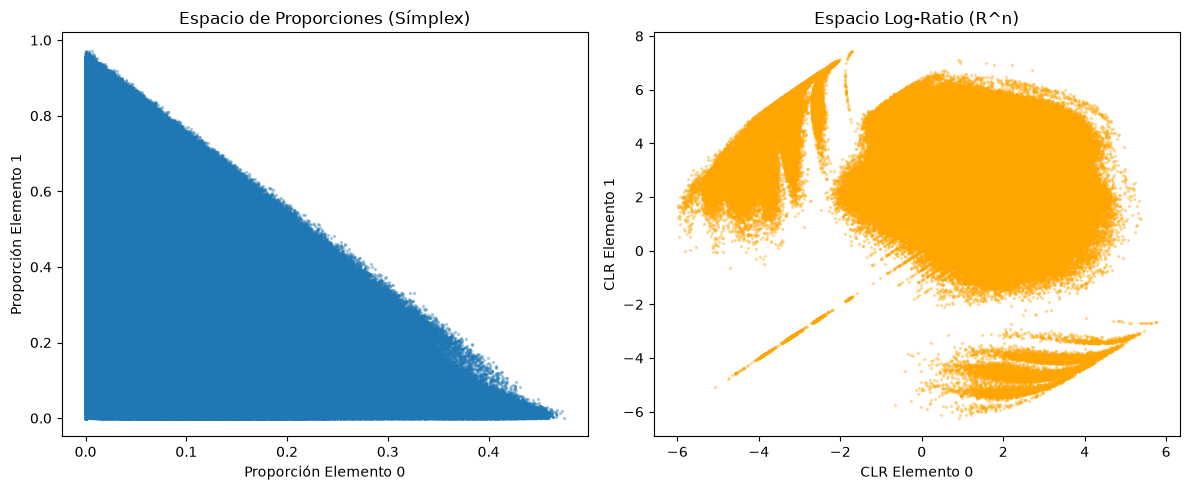

In [ ]:
# Comparative visualization of distributions (Channel 0 vs Channel 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original space (Proportions / SSimplex)
proportions = valid_pixels / np.sum(valid_pixels, axis=1, keepdims=True)
ax1.scatter(proportions[:, 0], proportions[:, 1], alpha=0.3, s=2)
ax1.set_title("Original Space (Proportions / SSimplex)")
ax1.set_xlabel("Proportion Element 0")
ax1.set_ylabel("Proportion Element 1")

# Euclidean space CLR
ax2.scatter(clr_data[:, 0], clr_data[:, 1], alpha=0.3, s=2, color="orange")
ax2.set_title("Euclidean Space (R^n)")
ax2.set_xlabel("CLR Element 0")
ax2.set_ylabel("CLR Elemento 1")

plt.tight_layout()
plt.show()